# Camera degradation health score — Kaggle mini benchmark

**Câu hỏi:** MUSIQ và độ nét có phản ánh mức giảm khả năng object detection khi ảnh bị blur, noise và che khuất không?

Notebook chạy inference, không train. Mặc định `MODE="smoke"` dùng 5 ảnh; đổi thành `"benchmark"` để dùng 50 ảnh và chạy lại từ cell cấu hình.

**Kaggle:** Import notebook → Settings: GPU T4/P100, Internet ON → Run All. Lần đầu cần Internet cho pip, COCO128 và pretrained weights. Nếu không có Internet, chuẩn bị packages/weights trước; cấu hình dataset và YOLO bên dưới. MUSIQ cũng cần weights đã cache hoặc tải sẵn.

**Giới hạn:** MUSIQ là điểm chất lượng cảm nhận, không phải điểm sức khỏe phần cứng hay xác suất detector đúng. COCO128 lấy từ COCO train2017 và có thể trùng dữ liệu huấn luyện của pretrained YOLO; chỉ dùng để thăm dò suy giảm trên cùng ảnh, không báo cáo generalization. Corruption là tổng hợp.

**Output:** CSV per-image/aggregate/correlation, 3 biểu đồ, một thử nghiệm che nền so với che mục tiêu, config, phiên bản packages và report tự động trong `/kaggle/working`.


In [12]:
# Không cài lại torch/torchvision riêng: ưu tiên bộ đã có trong Kaggle.
# Sau khi chạy, versions.json + pip-freeze.txt ghi lại phiên bản thực tế.
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       'ultralytics', 'pyiqa', 'scipy', 'pandas', 'matplotlib', 'tqdm'])


0

## 1. Cấu hình

Chạy smoke trước. Sau khi thành công, đổi MODE rồi chạy lại từ đây đến cuối.
`YOLO_WEIGHTS` có thể là đường dẫn trong `/kaggle/input/...`. `DATASET_ROOT` là thư mục chứa `images/train2017` và `labels/train2017`.
Các ngưỡng detection được cố định trên toàn bộ điều kiện. Không tùy chỉnh ngưỡng theo kết quả corruption.


In [13]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib, importlib.metadata, json, random, subprocess, time, warnings, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from scipy.ndimage import gaussian_filter, laplace
from scipy.stats import spearmanr
from tqdm.auto import tqdm
from IPython.display import display, FileLink
import torch
import pyiqa
from ultralytics import YOLO

MODE = 'benchmark'                    # 'smoke' (5 ảnh) hoặc 'benchmark' (50 ảnh)
SEED = 42
MAX_IMAGES = 5 if MODE == 'smoke' else 50
DATASET_ROOT = None                # ví dụ '/kaggle/input/coco128/coco128'
YOLO_WEIGHTS = 'yolo11n.pt'         # hoặc đường dẫn pretrained .pt của bạn
MUSIQ_WEIGHTS = None               # tùy chọn: đường dẫn weights MUSIQ tương thích pyiqa
USE_MUSIQ = True                   # False: chỉ chạy baseline độ nét, report ghi rõ
CONF_THRESHOLD = 0.25
MATCH_IOU = 0.50                   # IoU để ghép GT và prediction
NMS_IOU = 0.70                     # khác với MATCH_IOU
YOLO_IMGSZ = 640
MAX_IMAGE_SIDE = 960               # resize ảnh trước cả score/detection; GT đổi cùng ảnh
SAVE_CORRUPTED_IMAGES = True
FAILURE_SEARCH_IMAGES = 10
BLUR_SIGMAS = [1.0, 2.0, 4.0]
NOISE_SIGMAS = [5.0, 15.0, 30.0]    # trên thang 0..255
OCCLUSION_FRACTIONS = [0.05, 0.15, 0.30]

assert MODE in {'smoke', 'benchmark'}
assert 0 < CONF_THRESHOLD < 1 and 0 < MATCH_IOU <= 1
WORK = Path('/kaggle/working') if Path('/kaggle').exists() else Path.cwd() / 'camera_work'
WORK.mkdir(parents=True, exist_ok=True)
RUN_ID = datetime.now(timezone.utc).strftime('%Y%m%d_%H%M%S_%f')
OUT = WORK / f'camera_health_{MODE}_{RUN_ID}'
OUT.mkdir(parents=True)
DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
YOLO_DEVICE = 0 if torch.cuda.is_available() else 'cpu'
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

config = dict(mode=MODE, seed=SEED, max_images=MAX_IMAGES, yolo_weights=str(YOLO_WEIGHTS),
              musiq_weights=str(MUSIQ_WEIGHTS), use_musiq=USE_MUSIQ, conf=CONF_THRESHOLD,
              match_iou=MATCH_IOU, nms_iou=NMS_IOU, imgsz=YOLO_IMGSZ,
              max_image_side=MAX_IMAGE_SIDE, blur_sigmas=BLUR_SIGMAS,
              noise_sigmas=NOISE_SIGMAS, occlusion_fractions=OCCLUSION_FRACTIONS,
              failure_search_images=FAILURE_SEARCH_IMAGES, device=DEVICE)
(OUT / 'config.json').write_text(json.dumps(config, indent=2), encoding='utf-8')
versions = {p: importlib.metadata.version(p) for p in
            ['torch', 'torchvision', 'ultralytics', 'pyiqa', 'numpy', 'scipy', 'pandas']}
(OUT / 'versions.json').write_text(json.dumps(versions, indent=2))
(OUT / 'pip-freeze.txt').write_text(subprocess.check_output(
    [sys.executable, '-m', 'pip', 'freeze'], text=True))
print('Device:', DEVICE, '| Output:', OUT)
if DEVICE == 'cpu':
    print('CPU có thể chậm; nên dùng smoke hoặc bật GPU trong Kaggle Settings.')


Device: cuda:0 | Output: /kaggle/working/camera_health_benchmark_20261005_101808_840174


## 2. Dataset và models

Tự tìm dataset đã Add Input vào Kaggle; nếu không thấy thì tải COCO128 từ URL trong YAML chính thức của Ultralytics.
Notebook không train/finetune trên dataset này.


In [14]:
import urllib.request

def find_coco_root(base):
    base = Path(base)
    if (base / 'images/train2017').is_dir() and (base / 'labels/train2017').is_dir():
        return base
    for label_dir in sorted(base.rglob('labels/train2017')):
        candidate = label_dir.parent.parent
        if (candidate / 'images/train2017').is_dir():
            return candidate
    return None

if DATASET_ROOT is not None:
    data_root = find_coco_root(DATASET_ROOT)
    if data_root is None:
        raise FileNotFoundError('DATASET_ROOT phải chứa images/train2017 và labels/train2017.')
else:
    data_root = find_coco_root('/kaggle/input') if Path('/kaggle/input').exists() else None
    if data_root is None:
        data_root = find_coco_root(WORK / 'datasets') if (WORK / 'datasets').exists() else None
    if data_root is None:
        dataset_dir = WORK / 'datasets'
        dataset_dir.mkdir(exist_ok=True)
        archive = dataset_dir / 'coco128.zip'
        url = 'https://github.com/ultralytics/assets/releases/download/v0.0.0/coco128.zip'
        try:
            urllib.request.urlretrieve(url, archive)
            with zipfile.ZipFile(archive) as z:
                root = dataset_dir.resolve()
                for item in z.infolist():
                    if not (root / item.filename).resolve().is_relative_to(root):
                        raise ValueError('Unsafe archive path')
                z.extractall(dataset_dir)
        except Exception as e:
            raise RuntimeError('Tải COCO128 thất bại. Bật Internet hoặc Add Input COCO128 '
                               'và đặt DATASET_ROOT. Lỗi gốc: ' + str(e)) from e
        data_root = find_coco_root(dataset_dir)
        if data_root is None:
            raise FileNotFoundError('Archive không chứa cấu trúc COCO128 mong đợi.')

image_dir = data_root / 'images/train2017'
label_dir = data_root / 'labels/train2017'
all_paths = sorted(p for p in image_dir.iterdir() if p.suffix.lower() in {'.jpg','.jpeg','.png'})
# Chỉ dùng ảnh có GT; không để denominator=0 làm sai correlation.
eligible = [p for p in all_paths if (label_dir / (p.stem + '.txt')).is_file()
            and (label_dir / (p.stem + '.txt')).read_text().strip()]
rng = np.random.default_rng(SEED)
order = rng.permutation(len(eligible))
paths = [eligible[i] for i in order[:min(MAX_IMAGES, len(eligible))]]
assert paths, 'Không có ảnh có annotation.'
(OUT / 'selected_images.json').write_text(json.dumps([p.name for p in paths], indent=2))
config['dataset_root'] = str(data_root)
config['selected_images'] = [p.name for p in paths]
(OUT / 'config.json').write_text(json.dumps(config, indent=2))
print('Dataset:', data_root, '| Images:', len(paths), '| Conditions/image: 10')

detector = YOLO(str(YOLO_WEIGHTS))
assert len(detector.names) == 80, 'Notebook yêu cầu weights detection có taxonomy COCO 80 classes.'
assert detector.names[0] == 'person', 'Kiểm tra class mapping của weights với COCO128.'
iqa = None
if USE_MUSIQ:
    try:
        options = {'pretrained_model_path': str(MUSIQ_WEIGHTS)} if MUSIQ_WEIGHTS else {}
        iqa = pyiqa.create_metric('musiq', device=DEVICE, **options).eval()
        assert not iqa.lower_better, 'MUSIQ dự kiến higher-is-better.'
    except Exception as e:
        raise RuntimeError('Không load được MUSIQ. Kiểm tra Internet/weights và torch/torchvision. '
                           'Nếu chỉ chạy độ nét, đặt USE_MUSIQ=False rồi chạy lại từ cấu hình. '
                           'Không tự động thay score khác. Lỗi gốc: ' + str(e)) from e


Dataset: /kaggle/working/datasets/coco128 | Images: 50 | Conditions/image: 10
Loading pretrained model MUSIQ from /root/.cache/torch/hub/pyiqa/musiq_koniq_ckpt-e95806b9.pth


## 3. Hàm tạo corruption và đánh giá

- RGB cho MUSIQ, BGR NumPy cho Ultralytics; score và detection dùng cùng ảnh.
- Gaussian blur/noise áp dụng độc lập, không cộng dồn; severity là tham số mô phỏng.
- Occlusion dùng hình chữ nhật xám cố định vị trí theo image ID, tăng kích thước theo severity.
- Ghép prediction theo confidence giảm dần, cùng class, IoU ≥ 0.5, mỗi GT tối đa một prediction.
- `retention`: tỷ lệ GT được phát hiện trên ảnh sạch vẫn được phát hiện sau corruption. Nếu clean không phát hiện GT nào, retention là NaN.
- GT giữ nguyên sau che khuất: đo mất khả năng quan sát đối tượng gốc, không khẳng định đối tượng bị che vẫn nhìn thấy được.


In [15]:
def stable_seed(image_id, namespace):
    digest = hashlib.sha256(f'{SEED}:{image_id}:{namespace}'.encode()).digest()
    return int.from_bytes(digest[:8], 'little')

def load_image_gt(path):
    rgb = np.asarray(Image.open(path).convert('RGB'))
    h, w = rgb.shape[:2]
    scale = min(1.0, MAX_IMAGE_SIDE / max(h, w))
    if scale < 1:
        rgb = np.asarray(Image.fromarray(rgb).resize(
            (max(1, round(w * scale)), max(1, round(h * scale))), Image.Resampling.LANCZOS))
    h, w = rgb.shape[:2]
    rows = np.loadtxt(label_dir / f'{path.stem}.txt', ndmin=2)
    if rows.shape[1] != 5:
        raise ValueError(f'{path.name}: cần label cls xc yc width height dạng YOLO detection.')
    cls = rows[:, 0].astype(int)
    assert np.all(rows[:, 0] == cls) and np.all((cls >= 0) & (cls < 80))
    assert np.isfinite(rows).all() and np.all((rows[:, 1:] >= 0) & (rows[:, 1:] <= 1))
    xc, yc, bw, bh = rows[:, 1:].T
    boxes = np.column_stack(((xc - bw/2)*w, (yc - bh/2)*h,
                             (xc + bw/2)*w, (yc + bh/2)*h))
    boxes[:, [0, 2]] = boxes[:, [0, 2]].clip(0, w)
    boxes[:, [1, 3]] = boxes[:, [1, 3]].clip(0, h)
    assert np.all(boxes[:, 2:] > boxes[:, :2]), 'Degenerate GT box'
    return rgb.copy(), boxes, cls

def patch_xyxy(h, w, fraction, u, v):
    ph = min(h, max(1, round(h * np.sqrt(fraction))))
    pw = min(w, max(1, round(w * np.sqrt(fraction))))
    x = int(round(np.clip(u*w - pw/2, 0, w-pw)))
    y = int(round(np.clip(v*h - ph/2, 0, h-ph)))
    return (x, y, x+pw, y+ph)

def apply_patch(rgb, box):
    x1, y1, x2, y2 = map(int, box)
    out = rgb.copy()
    out[y1:y2, x1:x2] = 127
    return out

def corrupt(rgb, kind, severity, image_id):
    if kind == 'clean':
        return rgb.copy(), {'parameter': 0.0, 'actual_occlusion_fraction': 0.0}
    idx = severity - 1
    if kind == 'blur':
        sigma = BLUR_SIGMAS[idx]
        out = gaussian_filter(rgb.astype(np.float32), sigma=(sigma, sigma, 0), mode='reflect')
        return np.clip(np.rint(out), 0, 255).astype(np.uint8), {'parameter': sigma}
    if kind == 'noise':
        sigma = NOISE_SIGMAS[idx]
        # Cùng trường noise chuẩn hóa, amplitude tăng theo severity.
        noise = np.random.default_rng(stable_seed(image_id, 'noise')).normal(size=rgb.shape)
        out = np.clip(np.rint(rgb.astype(float) + sigma * noise), 0, 255).astype(np.uint8)
        return out, {'parameter': sigma}
    if kind == 'occlusion':
        h, w = rgb.shape[:2]
        fraction = OCCLUSION_FRACTIONS[idx]
        u, v = np.random.default_rng(stable_seed(image_id, 'occlusion')).uniform(0.2, 0.8, 2)
        box = patch_xyxy(h, w, fraction, u, v)
        x1,y1,x2,y2 = box
        return apply_patch(rgb, box), {'parameter': fraction,
               'actual_occlusion_fraction': (x2-x1)*(y2-y1)/(h*w), 'patch_box': list(box)}
    raise ValueError(kind)

def iou_matrix(a, b):
    a = np.asarray(a, dtype=float).reshape(-1, 4)
    b = np.asarray(b, dtype=float).reshape(-1, 4)
    lt = np.maximum(a[:, None, :2], b[None, :, :2])
    rb = np.minimum(a[:, None, 2:], b[None, :, 2:])
    inter = np.maximum(rb-lt, 0).prod(axis=2)
    aa = np.maximum(a[:, 2:]-a[:, :2], 0).prod(axis=1)
    ba = np.maximum(b[:, 2:]-b[:, :2], 0).prod(axis=1)
    return inter / np.maximum(aa[:, None] + ba[None, :] - inter, 1e-12)

def match_detections(pred_boxes, pred_cls, pred_conf, gt_boxes, gt_cls, threshold=0.5):
    overlaps = iou_matrix(pred_boxes, gt_boxes)
    matched_gt = np.zeros(len(gt_boxes), dtype=bool)
    matched_pred = np.zeros(len(pred_boxes), dtype=bool)
    for pi in np.argsort(-np.asarray(pred_conf), kind='stable'):
        candidates = np.flatnonzero((np.asarray(gt_cls) == pred_cls[pi]) & ~matched_gt)
        if not len(candidates):
            continue
        gi = candidates[np.argmax(overlaps[pi, candidates])]
        if overlaps[pi, gi] >= threshold:
            matched_gt[gi] = True
            matched_pred[pi] = True
    tp = int(matched_gt.sum()); fp = len(pred_boxes)-tp; fn = len(gt_boxes)-tp
    return {'tp':tp, 'fp':fp, 'fn':fn,
            'recall':tp/len(gt_boxes) if len(gt_boxes) else np.nan,
            'precision':tp/len(pred_boxes) if len(pred_boxes) else 0.0,
            'matched_gt':matched_gt, 'matched_pred':matched_pred}

@torch.inference_mode()
def evaluate_image(rgb, gt_boxes, gt_cls):
    gray = np.asarray(Image.fromarray(rgb).convert('L'), dtype=np.float32)
    sharpness = float(laplace(gray, mode='reflect').var())
    musiq = np.nan
    if iqa is not None:
        tensor = torch.from_numpy(np.ascontiguousarray(rgb.transpose(2,0,1))).float()
        tensor = tensor.unsqueeze(0).to(DEVICE) / 255.0
        musiq = float(iqa(tensor).item())
        if not np.isfinite(musiq):
            raise ValueError('MUSIQ returned non-finite score.')
    result = detector.predict(source=np.ascontiguousarray(rgb[:, :, ::-1]),
                              imgsz=YOLO_IMGSZ, conf=CONF_THRESHOLD, iou=NMS_IOU,
                              device=YOLO_DEVICE, verbose=False, max_det=300)[0]
    pb = result.boxes.xyxy.cpu().numpy()
    pc = result.boxes.cls.cpu().numpy().astype(int)
    conf = result.boxes.conf.cpu().numpy()
    metrics = match_detections(pb, pc, conf, gt_boxes, gt_cls, MATCH_IOU)
    return {'musiq':musiq, 'sharpness':sharpness, **metrics,
            'pred_boxes':pb, 'pred_cls':pc, 'pred_conf':conf}


## 4. Sanity checks và chạy thử một ảnh

Các check kiểm tra ghép một–một, class mismatch, zero prediction và corruption tái lập.
Sau đó một ảnh đi qua cả MUSIQ và YOLO để phát hiện lỗi môi trường trước benchmark.


Sanity checks passed.
{'image': '000000000404.jpg', 'musiq': 75.0298843383789, 'sharpness': 1491.1568603515625, 'recall': 0.2, 'seconds': 0.16}


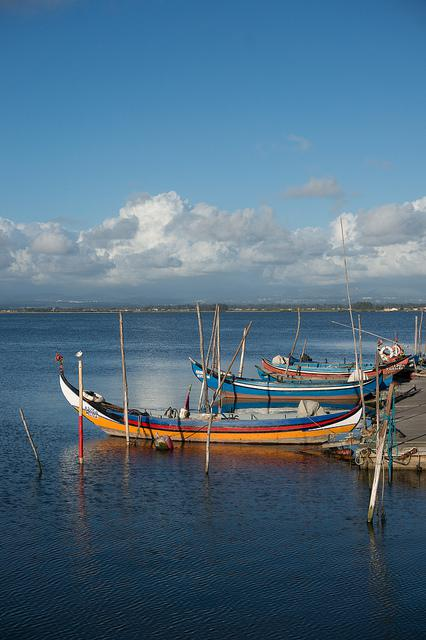

In [16]:
_gt = np.array([[0,0,10,10]], dtype=float)
_test = match_detections(np.vstack([_gt,_gt]), np.array([0,0]), np.array([0.9,0.8]), _gt, np.array([0]))
assert (_test['tp'],_test['fp'],_test['fn']) == (1,1,0)
assert match_detections(_gt,np.array([1]),np.array([0.9]),_gt,np.array([0]))['tp'] == 0
assert match_detections(np.empty((0,4)),np.array([],int),np.array([]),_gt,np.array([0]))['fn'] == 1
assert np.allclose(iou_matrix(_gt,_gt), 1)
assert np.isclose(iou_matrix(_gt, np.array([[5,0,15,10]]))[0,0], 1/3)
_tiny = np.full((40,60,3),128,np.uint8)
assert np.array_equal(corrupt(_tiny,'noise',2,'test')[0], corrupt(_tiny,'noise',2,'test')[0])
assert np.array_equal(corrupt(_tiny,'clean',0,'test')[0],_tiny)
for _kind in ['blur','noise','occlusion']:
    for _level in [1,2,3]:
        _img,_meta = corrupt(_tiny,_kind,_level,'test')
        assert _img.shape == _tiny.shape and _img.dtype == np.uint8
print('Sanity checks passed.')

smoke_rgb, smoke_boxes, smoke_cls = load_image_gt(paths[0])
t0 = time.perf_counter()
smoke = evaluate_image(smoke_rgb, smoke_boxes, smoke_cls)
print({'image':paths[0].name, 'musiq':smoke['musiq'], 'sharpness':smoke['sharpness'],
       'recall':smoke['recall'], 'seconds':round(time.perf_counter()-t0,2)})
display(Image.fromarray(smoke_rgb))


## 5. Chạy benchmark

Ghi checkpoint CSV sau từng ảnh nguồn. Giữ prediction trong bộ nhớ cho visualization; ảnh corrupted lưu PNG lossless nếu bật SAVE_CORRUPTED_IMAGES. Mỗi run có thư mục riêng để không trộn kết quả smoke và benchmark.


In [17]:
conditions = [('clean',0)] + [(kind,s) for kind in ['blur','noise','occlusion'] for s in [1,2,3]]
rows = []
prediction_cache = {}
clean_matches = {}
if SAVE_CORRUPTED_IMAGES:
    (OUT / 'images').mkdir(exist_ok=True)
started = time.perf_counter()
for path in tqdm(paths, desc='Source images'):
    rgb, gt_boxes, gt_cls = load_image_gt(path)
    baseline = None
    for kind, severity in conditions:
        img, meta = corrupt(rgb, kind, severity, path.stem)
        result = evaluate_image(img, gt_boxes, gt_cls)
        prediction_cache[(path.stem,kind,severity)] = result
        if kind == 'clean':
            baseline = result
            clean_matches[path.stem] = result['matched_gt'].copy()
        retained = int((result['matched_gt'] & baseline['matched_gt']).sum())
        retention = retained / baseline['tp'] if baseline['tp'] else np.nan
        row = dict(image_id=path.stem, image_name=path.name, corruption=kind, severity=severity,
                   parameter=meta['parameter'], musiq=result['musiq'], sharpness=result['sharpness'],
                   n_gt=len(gt_cls), n_pred=len(result['pred_cls']), tp=result['tp'], fp=result['fp'],
                   fn=result['fn'], recall=result['recall'], precision=result['precision'],
                   recall_clean=baseline['recall'], recall_drop=baseline['recall']-result['recall'],
                   clean_tp=baseline['tp'], retained_tp=retained, retention=retention,
                   actual_occlusion_fraction=meta.get('actual_occlusion_fraction',0.0))
        rows.append(row)
        if SAVE_CORRUPTED_IMAGES:
            Image.fromarray(img).save(OUT / 'images' / f'{path.stem}_{kind}_s{severity}.png')
    pd.DataFrame(rows).to_csv(OUT / 'per_image_results.csv',index=False)
results = pd.DataFrame(rows)
assert len(results) == len(paths)*10
assert not results.duplicated(['image_id','corruption','severity']).any()
assert np.allclose(results[results.corruption.eq('clean')].recall_drop,0)
print(f'Completed: {len(results)} images, {(time.perf_counter()-started)/60:.1f} minutes')
display(results.head(10))


Source images:   0%|          | 0/50 [00:00<?, ?it/s]

Completed: 500 images, 1.2 minutes


,image_id,image_name,corruption,severity,parameter,musiq,sharpness,n_gt,n_pred,tp,fp,fn,recall,precision,recall_clean,recall_drop,clean_tp,retained_tp,retention,actual_occlusion_fraction
0,000000000404,000000000404.jpg,clean,0,0.00,75.029884,1491.156860,5,1,1,0,4,0.2,1.0,0.2,0.0,1,1,1.0,0.000000
1,000000000404,000000000404.jpg,blur,1,1.00,52.320175,45.222652,5,1,1,0,4,0.2,1.0,0.2,0.0,1,1,1.0,0.000000
2,000000000404,000000000404.jpg,blur,2,2.00,27.131641,4.507783,5,1,1,0,4,0.2,1.0,0.2,0.0,1,1,1.0,0.000000
3,000000000404,000000000404.jpg,blur,3,4.00,21.225700,1.629776,5,1,1,0,4,0.2,1.0,0.2,0.0,1,1,1.0,0.000000
4,000000000404,000000000404.jpg,noise,1,5.00,71.847000,1711.388306,5,1,1,0,4,0.2,1.0,0.2,0.0,1,1,1.0,0.000000
5,000000000404,000000000404.jpg,noise,2,15.00,57.153786,3442.829834,5,2,1,1,4,0.2,0.5,0.2,0.0,1,1,1.0,0.000000
6,000000000404,000000000404.jpg,noise,3,30.00,45.287941,9025.539062,5,2,2,0,3,0.4,1.0,0.2,-0.2,1,1,1.0,0.000000
7,000000000404,000000000404.jpg,occlusion,1,0.05,74.834717,1445.486816,5,2,2,0,3,0.4,1.0,0.2,-0.2,1,1,1.0,0.049828
8,000000000404,000000000404.jpg,occlusion,2,0.15,74.326538,1114.809448,5,1,1,0,4,0.2,1.0,0.2,0.0,1,1,1.0,0.150088
9,000000000404,000000000404.jpg,occlusion,3,0.30,73.355865,695.946899,5,2,0,2,5,0.0,0.0,0.2,0.2,1,0,0.0,0.299967


## 6. Tổng hợp metrics và correlation

`micro_recall = ΣTP / ΣGT`; macro recall là trung bình recall từng ảnh.
Correlation dựa trên các cặp score/recall từng ảnh, loại clean khỏi phân tích corruption. Không dùng severity làm ground truth của health score.

Các bản corrupted của cùng ảnh không độc lập. Correlation/p-value không dùng như bằng chứng kiểm định thống kê trên nhiều mẫu độc lập. Đây là benchmark thăm dò, không báo cáo CI giả từ số ảnh corrupted.


In [18]:
summary = results.groupby(['corruption','severity'],as_index=False).agg(
    n_images=('image_id','size'), musiq_mean=('musiq','mean'), sharpness_mean=('sharpness','mean'),
    macro_recall=('recall','mean'), macro_precision=('precision','mean'),
    recall_drop_mean=('recall_drop','mean'), retention_macro=('retention','mean'),
    tp=('tp','sum'), fp=('fp','sum'), n_gt=('n_gt','sum'),
    clean_tp=('clean_tp','sum'), retained_tp=('retained_tp','sum'))
summary['micro_recall'] = summary.tp / summary.n_gt
summary['micro_precision'] = summary.tp / (summary.tp + summary.fp).replace(0,np.nan)
summary['retention_micro'] = summary.retained_tp / summary.clean_tp.replace(0,np.nan)
summary.to_csv(OUT / 'summary.csv',index=False)
display(summary.round(4))

def safe_spearman(x,y):
    x = np.asarray(x,dtype=float); y = np.asarray(y,dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    if valid.sum() < 3 or np.unique(x[valid]).size < 2 or np.unique(y[valid]).size < 2:
        return np.nan, int(valid.sum())
    return float(spearmanr(x[valid],y[valid]).statistic), int(valid.sum())

corr_rows = []
corrupted = results[results.corruption.ne('clean')]
for group in ['all','blur','noise','occlusion']:
    sub = corrupted if group == 'all' else corrupted[corrupted.corruption.eq(group)]
    for score in ['musiq','sharpness']:
        if score == 'musiq' and iqa is None:
            continue
        for outcome in ['recall','retention']:
            rho,n = safe_spearman(sub[score],sub[outcome])
            corr_rows.append(dict(corruption=group,score=score,outcome=outcome,rho=rho,n_pairs=n))
correlations = pd.DataFrame(corr_rows)
correlations.to_csv(OUT / 'correlations.csv',index=False)
display(correlations.round(3))

# Tỷ lệ bước severity làm score giảm hoặc bằng trên cùng ảnh: lớn hơn là tốt.
monotonic = []
for kind in ['blur','noise','occlusion']:
    for score in ['musiq','sharpness']:
        if score == 'musiq' and iqa is None: continue
        sub = pd.concat([results[results.corruption.eq('clean')],
                         results[results.corruption.eq(kind)]])
        mat = sub.pivot(index='image_id',columns='severity',values=score).sort_index(axis=1)
        delta = np.diff(mat.to_numpy(),axis=1)
        monotonic.append(dict(corruption=kind,score=score,
                              fraction_nonincreasing_steps=float((delta <= 0).mean())))
monotonicity = pd.DataFrame(monotonic)
monotonicity.to_csv(OUT / 'monotonicity.csv',index=False)
display(monotonicity.round(3))


,corruption,severity,n_images,musiq_mean,sharpness_mean,macro_recall,macro_precision,recall_drop_mean,retention_macro,tp,fp,n_gt,clean_tp,retained_tp,micro_recall,micro_precision,retention_micro
0,blur,1,50,50.4203,82.9801,0.6885,0.8187,0.0125,0.9510,202,73,411,208,192,0.4915,0.7345,0.9231
1,blur,2,50,27.0100,8.9944,0.6323,0.7878,0.0687,0.8430,168,66,411,208,162,0.4088,0.7179,0.7788
2,blur,3,50,17.6828,2.3405,0.4172,0.6482,0.2838,0.5510,102,41,411,208,100,0.2482,0.7133,0.4808
3,clean,0,50,69.9576,2395.0193,0.7010,0.8045,0.0000,1.0000,208,83,411,208,208,0.5061,0.7148,1.0000
4,noise,1,50,67.4563,2605.0868,0.6827,0.8195,0.0184,0.9617,204,78,411,208,199,0.4964,0.7234,0.9567
5,noise,2,50,56.6854,4237.3942,0.5985,0.8151,0.1026,0.8126,167,56,411,208,163,0.4063,0.7489,0.7837
6,noise,3,50,46.4536,9330.9327,0.3949,0.6441,0.3061,0.5551,113,52,411,208,112,0.2749,0.6848,0.5385
7,occlusion,1,50,69.6882,2270.3952,0.6497,0.7756,0.0514,0.9129,191,86,411,208,187,0.4647,0.6895,0.8990
8,occlusion,2,50,68.0853,2012.1868,0.5122,0.5958,0.1888,0.6872,155,128,411,208,145,0.3771,0.5477,0.6971
9,occlusion,3,50,65.4992,1630.7290,0.3988,0.4408,0.3023,0.5091,120,121,411,208,110,0.2920,0.4979,0.5288


,corruption,score,outcome,rho,n_pairs
0,all,musiq,recall,0.078,450
1,all,musiq,retention,0.131,450
2,all,sharpness,recall,-0.105,450
3,all,sharpness,retention,-0.081,450
4,blur,musiq,recall,0.359,150
5,blur,musiq,retention,0.487,150
6,blur,sharpness,recall,0.223,150
7,blur,sharpness,retention,0.393,150
8,noise,musiq,recall,0.243,150
9,noise,musiq,retention,0.430,150


,corruption,score,fraction_nonincreasing_steps
0,blur,musiq,1.000
1,blur,sharpness,1.000
2,noise,musiq,0.987
3,noise,sharpness,0.000
4,occlusion,musiq,0.800
5,occlusion,sharpness,0.913


## 7. Biểu đồ

Score không được min–max trên test để gọi là health %. Trục MUSIQ dùng giá trị native. Baseline độ nét chỉ đo cấu trúc tần số cao, noise có thể làm nó tăng.


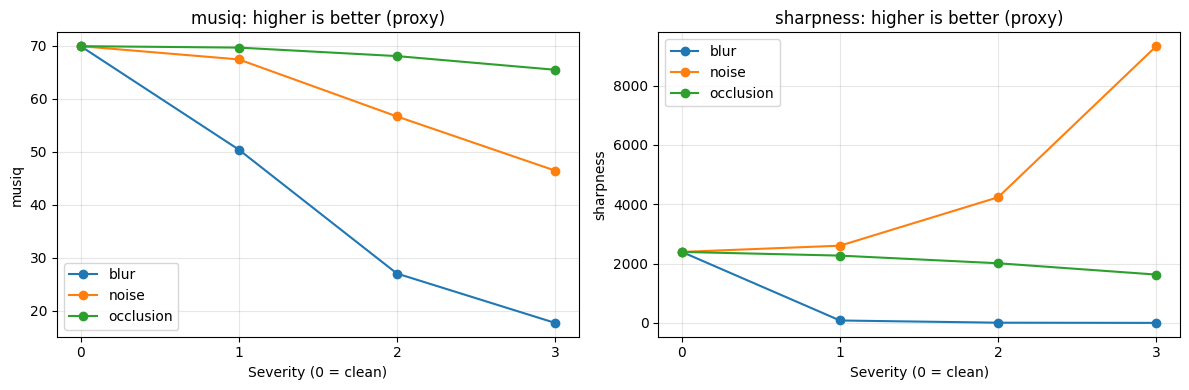

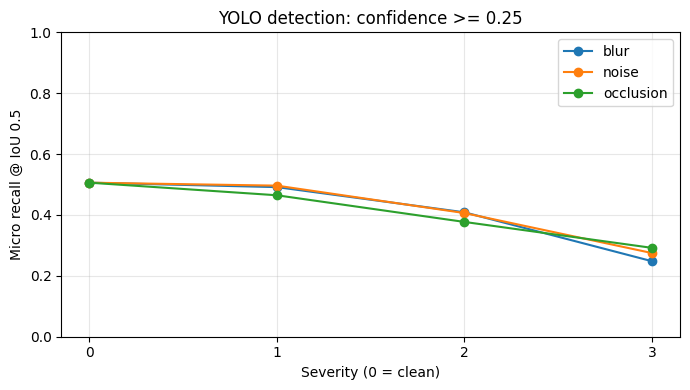

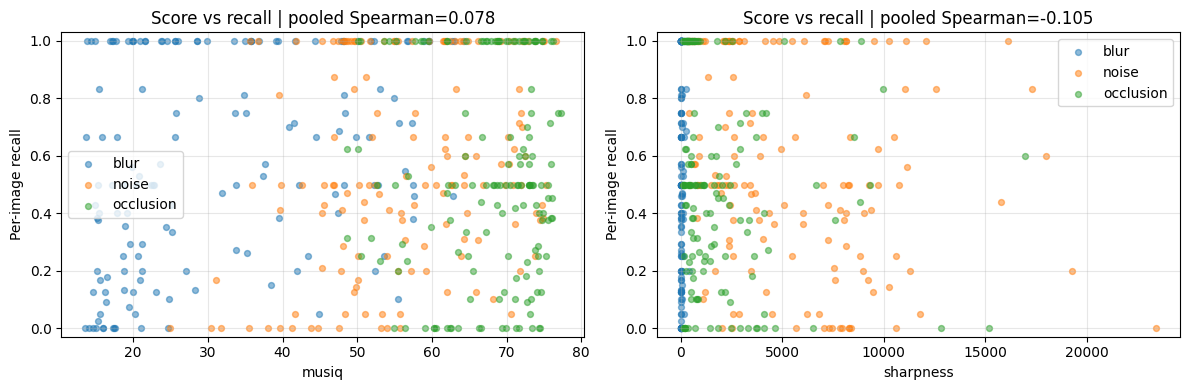

In [19]:
colors = {'blur':'tab:blue','noise':'tab:orange','occlusion':'tab:green'}
score_names = ['musiq','sharpness'] if iqa is not None else ['sharpness']
fig,axes = plt.subplots(1,len(score_names),figsize=(6*len(score_names),4),squeeze=False)
for ax,score in zip(axes[0],score_names):
    for kind,color in colors.items():
        sub = pd.concat([summary[summary.corruption.eq('clean')],
                         summary[summary.corruption.eq(kind)]]).sort_values('severity')
        ax.plot(sub.severity,sub[score+'_mean'],'o-',label=kind,color=color)
    ax.set(xlabel='Severity (0 = clean)',ylabel=score,title=f'{score}: higher is better (proxy)')
    ax.set_xticks([0,1,2,3]); ax.grid(alpha=0.3); ax.legend()
fig.tight_layout(); fig.savefig(OUT/'quality_vs_severity.png',dpi=160); plt.show()

fig,ax = plt.subplots(figsize=(7,4))
for kind,color in colors.items():
    sub = pd.concat([summary[summary.corruption.eq('clean')],
                     summary[summary.corruption.eq(kind)]]).sort_values('severity')
    ax.plot(sub.severity,sub.micro_recall,'o-',label=kind,color=color)
ax.set(xlabel='Severity (0 = clean)',ylabel='Micro recall @ IoU 0.5',ylim=(0,1),
       title=f'YOLO detection: confidence >= {CONF_THRESHOLD}')
ax.set_xticks([0,1,2,3]); ax.grid(alpha=0.3); ax.legend()
fig.tight_layout(); fig.savefig(OUT/'recall_vs_severity.png',dpi=160); plt.show()

fig,axes = plt.subplots(1,len(score_names),figsize=(6*len(score_names),4),squeeze=False)
for ax,score in zip(axes[0],score_names):
    for kind,color in colors.items():
        sub = corrupted[corrupted.corruption.eq(kind)]
        ax.scatter(sub[score],sub.recall,s=18,alpha=0.5,label=kind,color=color)
    rho,n = safe_spearman(corrupted[score],corrupted.recall)
    ax.set(xlabel=score,ylabel='Per-image recall',ylim=(-0.03,1.03),
           title=f'Score vs recall | pooled Spearman={rho:.3f}')
    ax.grid(alpha=0.3); ax.legend()
fig.tight_layout(); fig.savefig(OUT/'quality_vs_recall.png',dpi=160); plt.show()


## 8. Failure case: cùng diện tích che, khác vị trí

Tìm mục tiêu được phát hiện trên clean và một vùng nền không giao bất kỳ GT bounding box nào. Dùng patch cùng kích thước/màu để che nền và che mục tiêu; giữ nguyên ảnh và inference config.

Tìm tối đa FAILURE_SEARCH_IMAGES ảnh đã benchmark. Chỉ gọi là **candidate failure** nếu mục tiêu còn được phát hiện khi che nền nhưng mất khi che mục tiêu. Mức giống nhau của score phải được xem trên số đo, không mặc định là giống. Nếu không tìm thấy, ghi rõ và xuất ví dụ thử nghiệm tốt nhất.


In [20]:
def rectangle_intersections(rect, boxes):
    rect = np.asarray(rect,dtype=float)
    lt = np.maximum(rect[:2], boxes[:,:2])
    rb = np.minimum(rect[2:], boxes[:,2:])
    return np.maximum(rb-lt,0).prod(axis=1)

def paired_patches(rgb, boxes, target_idx):
    h,w = rgb.shape[:2]
    box = boxes[target_idx]
    # Patch cố gắng che hết mục tiêu, nhưng không quá 85% mỗi chiều.
    pw = min(w,max(1,min(round(w*0.85),int(np.ceil((box[2]-box[0])*1.1)))))
    ph = min(h,max(1,min(round(h*0.85),int(np.ceil((box[3]-box[1])*1.1)))))
    cx,cy = (box[:2]+box[2:])/2
    x=int(round(np.clip(cx-pw/2,0,w-pw))); y=int(round(np.clip(cy-ph/2,0,h-ph)))
    target=(x,y,x+pw,y+ph)
    background=None
    for by in np.unique(np.linspace(0,h-ph,16).astype(int)):
        for bx in np.unique(np.linspace(0,w-pw,16).astype(int)):
            candidate=(int(bx),int(by),int(bx+pw),int(by+ph))
            if not rectangle_intersections(candidate,boxes).any():
                background=candidate
                break
        if background is not None: break
    return background,target

pair_rows=[]
best_pair=None
best_rank=None
for path in paths[:FAILURE_SEARCH_IMAGES]:
    rgb,boxes,cls=load_image_gt(path)
    clean=prediction_cache[(path.stem,'clean',0)]
    eligible_targets=np.flatnonzero(clean['matched_gt'])
    if not len(eligible_targets): continue
    areas=(boxes[:,2]-boxes[:,0])*(boxes[:,3]-boxes[:,1])
    for ti in sorted(eligible_targets,key=lambda j:-areas[j])[:5]:
        bg_patch,target_patch=paired_patches(rgb,boxes,ti)
        if bg_patch is None: continue
        variants={'clean':rgb,'background':apply_patch(rgb,bg_patch),
                  'target':apply_patch(rgb,target_patch)}
        evaluations={'clean':clean}
        for variant in ['background','target']:
            evaluations[variant]=evaluate_image(variants[variant],boxes,cls)
        bg_ok=bool(evaluations['background']['matched_gt'][ti])
        target_ok=bool(evaluations['target']['matched_gt'][ti])
        is_failure=bg_ok and not target_ok
        q_gap=abs(evaluations['background']['musiq']-evaluations['target']['musiq'])
        for variant in ['clean','background','target']:
            ev=evaluations[variant]
            pair_rows.append(dict(image_id=path.stem,target_gt_index=int(ti),
                target_class=detector.names[int(cls[ti])],variant=variant,
                target_detected=bool(ev['matched_gt'][ti]),musiq=ev['musiq'],
                sharpness=ev['sharpness'],recall=ev['recall'],
                patch_area_fraction=0 if variant=='clean' else
                    (target_patch[2]-target_patch[0])*(target_patch[3]-target_patch[1])/(rgb.shape[0]*rgb.shape[1]),
                candidate_failure=is_failure,musiq_gap=q_gap))
        # Ưu tiên mất target thật; trong các candidate, ưu tiên score gap nhỏ.
        rank=(int(is_failure), -q_gap if np.isfinite(q_gap) else 0)
        if best_rank is None or rank>best_rank:
            best_rank=rank
            best_pair=(path,boxes,cls,int(ti),variants,evaluations,bg_patch,target_patch,is_failure)
        break
pairs=pd.DataFrame(pair_rows)
if len(pairs):
    pairs.to_csv(OUT/'occlusion_pairs.csv',index=False)
    display(pairs.round(3))
    print('Candidate failure found:', bool(pairs.candidate_failure.any()))
else:
    print('Chưa có cặp hợp lệ: không tìm được vùng nền không giao GT. '
          'Tăng số ảnh rồi chạy lại benchmark/failure search.')


,image_id,target_gt_index,target_class,variant,target_detected,musiq,sharpness,recall,patch_area_fraction,candidate_failure,musiq_gap
0,000000000404,0,boat,clean,True,75.030,1491.157,0.200,0.000,True,2.769
1,000000000404,0,boat,background,True,74.393,1491.443,0.200,0.122,True,2.769
2,000000000404,0,boat,target,False,71.624,767.701,0.000,0.122,True,2.769
3,000000000030,1,vase,clean,True,72.425,612.482,1.000,0.000,True,5.697
4,000000000030,1,vase,background,True,72.333,620.464,1.000,0.144,True,5.697
5,000000000030,1,vase,target,False,66.636,427.135,0.000,0.144,True,5.697
6,000000000542,4,person,clean,True,55.744,2024.320,0.529,0.000,True,0.890
7,000000000542,4,person,background,True,56.488,2023.625,0.529,0.025,True,0.890
8,000000000542,4,person,target,False,57.378,1900.002,0.529,0.025,True,0.890
9,000000000472,0,airplane,clean,True,54.034,168.468,1.000,0.000,True,0.725


Candidate failure found: True


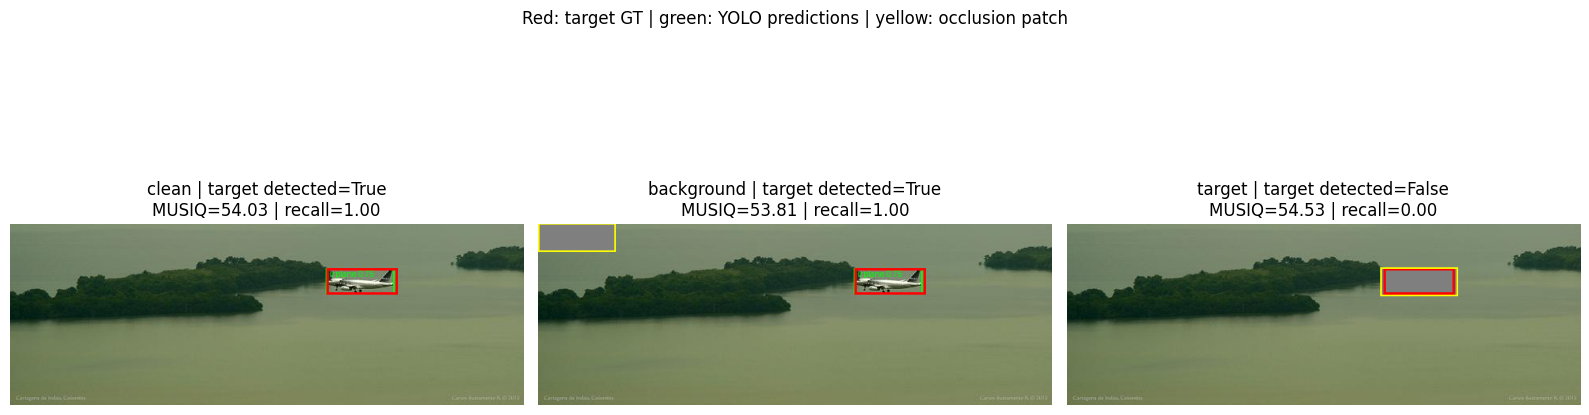

Image 000000000472.jpg, target=airplane, background detected=True, target-patch detected=False; MUSIQ gap=0.725; candidate failure=True.
Đã có target loss do vị trí che. Xem MUSIQ gap để đánh giá score có phân biệt được hay không.


In [21]:
def draw_detections(rgb, ev, target_box=None, patch=None):
    canvas=Image.fromarray(rgb).copy()
    draw=ImageDraw.Draw(canvas)
    for box,cls,conf in zip(ev['pred_boxes'],ev['pred_cls'],ev['pred_conf']):
        draw.rectangle(tuple(map(float,box)),outline='lime',width=2)
        draw.text((float(box[0]),float(box[1])),f'{detector.names[int(cls)]} {conf:.2f}',fill='lime')
    if target_box is not None:
        draw.rectangle(tuple(map(float,target_box)),outline='red',width=3)
    if patch is not None:
        draw.rectangle(tuple(map(int,patch)),outline='yellow',width=2)
    return canvas

failure_note='No valid occlusion pair found.'
if best_pair is not None:
    path,boxes,cls,ti,variants,evs,bg_patch,target_patch,is_failure=best_pair
    fig,axes=plt.subplots(1,3,figsize=(16,6))
    for ax,variant in zip(axes,['clean','background','target']):
        patch=None if variant=='clean' else bg_patch if variant=='background' else target_patch
        canvas=draw_detections(variants[variant],evs[variant],boxes[ti],patch)
        canvas.save(OUT/f'failure_{variant}.png')
        ax.imshow(canvas); ax.axis('off')
        ax.set_title(f"{variant} | target detected={bool(evs[variant]['matched_gt'][ti])}\n"
                     f"MUSIQ={evs[variant]['musiq']:.2f} | recall={evs[variant]['recall']:.2f}")
    fig.suptitle('Red: target GT | green: YOLO predictions | yellow: occlusion patch')
    fig.tight_layout(); fig.savefig(OUT/'failure_case.png',dpi=160); plt.show()
    gap=abs(evs['background']['musiq']-evs['target']['musiq'])
    failure_note=(f"Image {path.name}, target={detector.names[int(cls[ti])]}, "
        f"background detected={bool(evs['background']['matched_gt'][ti])}, "
        f"target-patch detected={bool(evs['target']['matched_gt'][ti])}; "
        f"MUSIQ gap={gap:.3f}; candidate failure={is_failure}.")
    print(failure_note)
    if is_failure:
        print('Đã có target loss do vị trí che. Xem MUSIQ gap để đánh giá score có phân biệt được hay không.')
    else:
        print('Ví dụ này chưa chứng minh failure hypothesis; không kết luận score thất bại.')


## 9. Report và tải output

Report chỉ điền số đo đã chạy. Không tự kết luận giả thuyết đúng. Zip chứa CSV, plots, config và ảnh nếu bật lưu.
Đổi sang benchmark sau smoke; giữ smoke làm kiểm tra môi trường, không dùng thay kết quả 50 ảnh.


In [22]:
clean_summary=summary[summary.corruption.eq('clean')].iloc[0]
lines=[
    '# Camera degradation mini benchmark',
    '',
    f'- Run: {MODE}; source images: {len(paths)}; evaluated images: {len(results)}.',
    f'- Detector: {YOLO_WEIGHTS}; confidence={CONF_THRESHOLD}; match IoU={MATCH_IOU}.',
    f'- MUSIQ enabled: {iqa is not None}. Scores are IQA proxies, not calibrated physical health.',
    f'- Clean micro recall: {clean_summary.micro_recall:.4f}.',
    '',
    '## Recall at severe corruption',
]
for kind in ['blur','noise','occlusion']:
    s=summary[(summary.corruption==kind)&(summary.severity==3)].iloc[0]
    lines.append(f'- {kind}: recall={s.micro_recall:.4f}, retention={s.retention_micro:.4f}, '
                 f'MUSIQ={s.musiq_mean:.3f}, sharpness={s.sharpness_mean:.3f}.')
lines+=['','## Correlations (exploratory, repeated source images)']
for row in correlations.itertuples():
    lines.append(f'- {row.corruption}: {row.score} vs {row.outcome}, rho={row.rho:.3f}, n={row.n_pairs}.')
lines+=['','## Paired occlusion test',failure_note,'',
    '## Interpretation checklist',
    '- Does each score decrease with severity for each corruption?',
    '- Does noise increase Laplacian variance despite detection degradation?',
    '- Does a small native MUSIQ difference coexist with target loss in the paired test?',
    '- If no candidate is found, report that outcome; do not invent a failure case.',
    '',
    '## Limitations',
    '- COCO128 is a training subset; pretrained detector may have seen these images.',
    '- Small sample, one detector, synthetic corruptions; no physical camera diagnosis.',
    '- Occluded targets keep original GT: recall measures loss of observability.',
    '- Constant confidence threshold; results are threshold-dependent.',
    '- Correlation may reflect content difficulty; paired recall drop/retention supplement it.',
    '- No claims of statistical significance from repeated corrupted versions.',
    '',
    '## Proposed improvement',
    'Evaluate regional quality with task-relevant weighting on a held-out validation dataset.',
    'Do not use ground-truth ROIs at deployment; define an independent ROI mechanism.',
    '',
    '## Sources',
    '- MUSIQ: https://openaccess.thecvf.com/content/ICCV2021/html/Ke_MUSIQ_Multi-Scale_Image_Quality_Transformer_ICCV_2021_paper.html',
    '- IQA-PyTorch: https://github.com/chaofengc/IQA-PyTorch',
    '- COCO128: https://docs.ultralytics.com/datasets/detect/coco128/',
    '- Ultralytics prediction API: https://docs.ultralytics.com/modes/predict/',
]
(OUT/'report.md').write_text('\n'.join(lines)+'\n',encoding='utf-8')
import shutil
zip_path=Path(shutil.make_archive(str(OUT),'zip',root_dir=OUT))
print('Outputs:',OUT)
display(FileLink(str(zip_path)))
print((OUT/'report.md').read_text())


Outputs: /kaggle/working/camera_health_benchmark_20261005_101808_840174


/kaggle/working/camera_health_benchmark_20261005_101808_840174.zip

# Camera degradation mini benchmark

- Run: benchmark; source images: 50; evaluated images: 500.
- Detector: yolo11n.pt; confidence=0.25; match IoU=0.5.
- MUSIQ enabled: True. Scores are IQA proxies, not calibrated physical health.
- Clean micro recall: 0.5061.

## Recall at severe corruption
- blur: recall=0.2482, retention=0.4808, MUSIQ=17.683, sharpness=2.341.
- noise: recall=0.2749, retention=0.5385, MUSIQ=46.454, sharpness=9330.933.
- occlusion: recall=0.2920, retention=0.5288, MUSIQ=65.499, sharpness=1630.729.

## Correlations (exploratory, repeated source images)
- all: musiq vs recall, rho=0.078, n=450.
- all: musiq vs retention, rho=0.131, n=450.
- all: sharpness vs recall, rho=-0.105, n=450.
- all: sharpness vs retention, rho=-0.081, n=450.
- blur: musiq vs recall, rho=0.359, n=150.
- blur: musiq vs retention, rho=0.487, n=150.
- blur: sharpness vs recall, rho=0.223, n=150.
- blur: sharpness vs retention, rho=0.393, n=150.
- noise: musiq vs recall, rho=0.243, n=150.
- noise: 

## Pitch 3–5 phút

1. **Câu hỏi:** score toàn ảnh có đủ đại diện cho độ tin cậy detection không?
2. **Thiết kế:** 50 ảnh nguồn, 3 corruption × 3 severity, fixed pretrained models và threshold.
3. **Kết quả:** dùng số đo thực tế từ summary/correlation và 2 biểu đồ chính.
4. **Failure/negative result:** ảnh paired occlusion; nói rõ target loss và MUSIQ gap đo được.
5. **Limitation + cải tiến:** synthetic corruption, COCO train overlap, một detector; kiểm tra regional score trên dữ liệu held-out thực tế.

Nếu timeout hoặc lỗi môi trường: giảm MAX_IMAGES, chạy USE_MUSIQ=False nếu không lấy được weights; lúc đó báo cáo chỉ baseline sharpness, không gán nó là MUSIQ.
